In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.patches as patches
import matplotlib.colors as colors

mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]
# Heatmap utils
heatmapmin, heatmapmax = 0.8, 1.2
def setheatmapminmax(min, max):
    global heatmapmin, heatmapmax
    heatmapmin, heatmapmax = min, max
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]
mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)
ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)
ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)
scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))
for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i
for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072
def getcolor(value, cmap = 'RdBu_r', numdiscretecolors = 20):
        colormap = plt.get_cmap(cmap)
        if value < heatmapmin:
            return colormap(0.0)
        elif value > heatmapmax:
            return colormap(1.0)
        else:
            return colormap((value - heatmapmin) / (heatmapmax - heatmapmin) * (numdiscretecolors - 2) // 1 / (numdiscretecolors - 2))
def makeheatmap(countsIDorder,title, name, savepath, heatmapmin = 0.80, heatmapmax = 1.20):
    setheatmapminmax(heatmapmin, heatmapmax)
    heatmapL = np.zeros((32, 96))
    heatmapR = np.zeros((32, 96))
    for i in range(3072):
        index = np.where(scanner_arc_R == i)
        heatmapR[index] = countsIDorder[i]
    for i in range(3072, 6144):
        index = np.where(scanner_arc_L == i)
        heatmapL[index] = countsIDorder[i]
    #heatmapR = heatmapR / np.median(heatmapR)
    #heatmapL = heatmapL / np.median(heatmapL)
    #Dead cells
    for i in range(32):
        for j in range(96):
            if heatmapR[i, j] == 0 or np.isnan(heatmapR[i, j]):
                heatmapR[i, j] = -1
            if heatmapL[i, j] == 0 or np.isnan(heatmapL[i, j]):
                heatmapL[i, j] = -1

    face_dim = 3.2
    space = 1.2
    blank_color = 'black'
    cmap = plt.get_cmap('viridis') # 'seismic' or 'RdBu' or 'rwb'
        
    fig, ax = plt.subplots(figsize = (8, 6))

    #rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
    #ax.add_patch(rect)

    # Plot R
    for z in range(32):
        zspace = z // 8 * space
        for y in range(96):
            yspace = y // 8 * space
            if heatmapR[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)

    # Plot L
    for z in range(32):
        zspace = z // 8 * space 
        for y in range(96):
            yspace = y // 8 * space
            if heatmapL[z, y] != -1:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y], cmap = cmap))
                ax = plt.gca()
                ax.add_patch(rect)
            else:
                rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
                ax = plt.gca()
                ax.add_patch(rect)
    bounds = np.linspace(heatmapmin, heatmapmax, 21)
    norm = colors.BoundaryNorm(bounds, cmap.N)
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
    diff = heatmapmax - heatmapmin
    cbar.set_ticks([heatmapmin, heatmapmin+diff*0.0, heatmapmin+diff*0.1, heatmapmin+diff*0.15, heatmapmin+diff*0.2, heatmapmin+diff*0.25, heatmapmin+diff*0.3, heatmapmin+diff*0.35, heatmapmin+diff*0.4, heatmapmin+diff*0.45, heatmapmin+diff*0.5, heatmapmin+diff*0.55, heatmapmin+diff*0.6, heatmapmin+diff*0.65, heatmapmin+diff*0.7, heatmapmin+diff*0.75, heatmapmin+diff*0.8, heatmapmin+diff*0.85, heatmapmin+diff*0.9, heatmapmin+diff*0.95, heatmapmax])
    cbar.set_ticklabels([
        '',
        #f'{heatmapmin:.2e}',
        f'{heatmapmin}',
        '', '', '', '', '', '', '', '',
        '',
        '', '', '', '', '', '', '', '', '',
        f'{heatmapmax}'
    ])
    plt.xlim(-2,322.4)
    pady = 36
    plt.ylim(-104.8 - pady, 113.2)
    plt.axis('off')
    #plt.tight_layout()
    plt.title(title)
    plt.savefig(os.path.join(savepath, f'{name}heatmap.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [3]:
names = ['hcenter', 'mcenter', 'hcirc', 'hvert']
path = '/home/kale-chen/Documents/PET/TPPT2026/data'
savepath = '/home/kale-chen/Documents/PET/TPPT2026/writeup/plots'
ppbounds = []
for name in names:
    ppath = os.path.join(path, f'{name}_ppbounds.txt')
    ppbound = np.loadtxt(ppath)
    toappend = np.column_stack((ppbound, (ppbound[:, 0] + ppbound[:, 1]) / 2, (ppbound[:, 1] - ppbound[:, 0]) * 2.355 / 5))
    ppbounds.append(toappend)


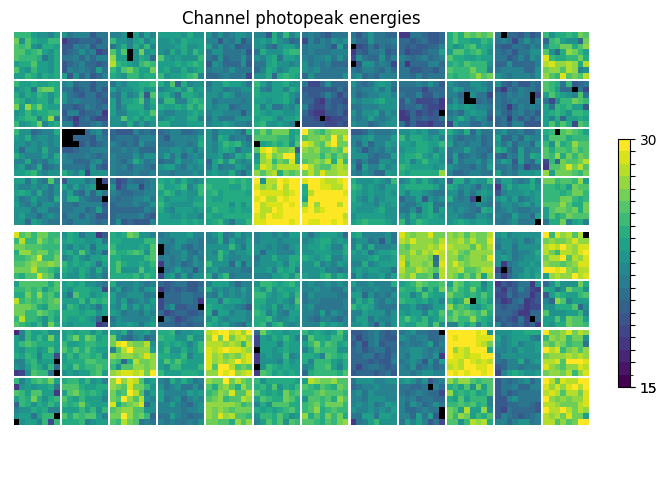

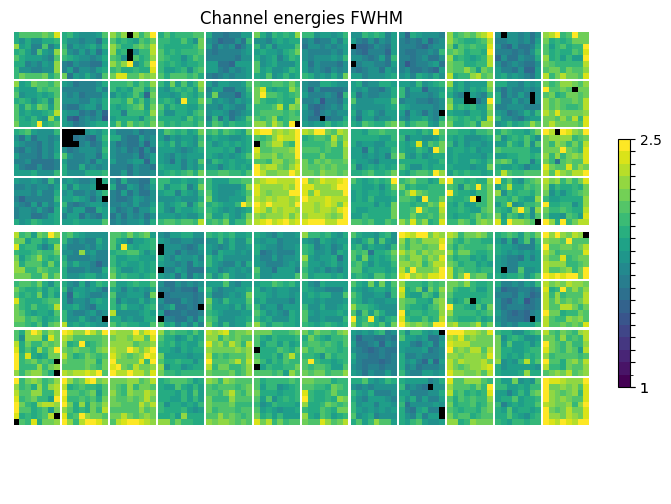

/tmp/ipykernel_2090757/1336000224.py:4: RuntimeWarning: invalid value encountered in divide
  makeheatmap(ppbounds[i][:, 3] / ppbounds[i][:, 2], 'Channel energy resolution', f'{names[i]}eres', savepath, heatmapmin = 0.06, heatmapmax = 0.12)


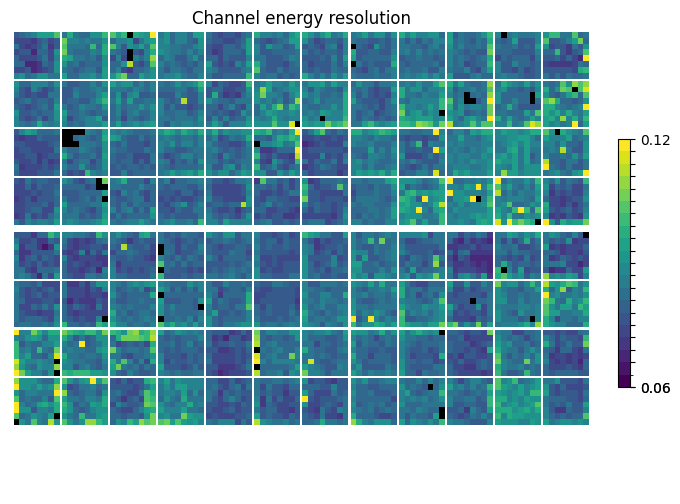

/tmp/ipykernel_2090757/1336000224.py:6: RuntimeWarning: invalid value encountered in divide
  eres = ppbounds[i][:, 3] / ppbounds[i][:, 2]


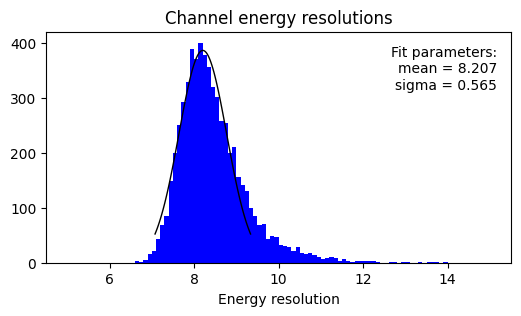

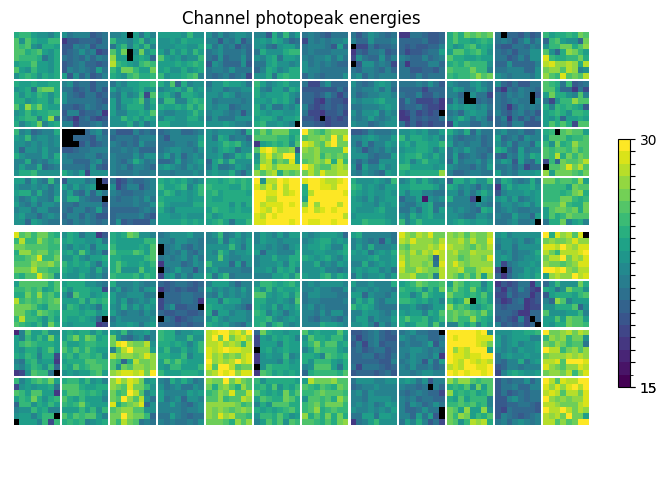

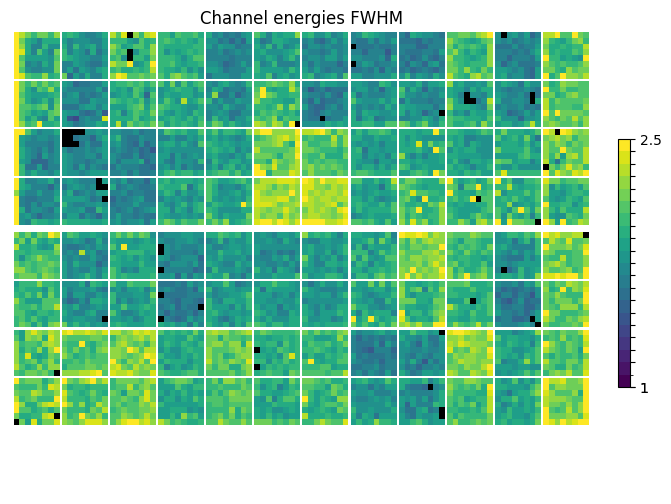

/tmp/ipykernel_2090757/1336000224.py:4: RuntimeWarning: invalid value encountered in divide
  makeheatmap(ppbounds[i][:, 3] / ppbounds[i][:, 2], 'Channel energy resolution', f'{names[i]}eres', savepath, heatmapmin = 0.06, heatmapmax = 0.12)


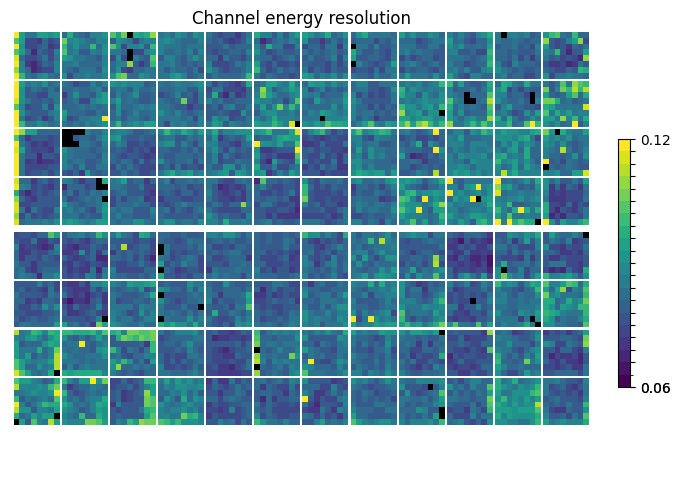

/tmp/ipykernel_2090757/1336000224.py:6: RuntimeWarning: invalid value encountered in divide
  eres = ppbounds[i][:, 3] / ppbounds[i][:, 2]


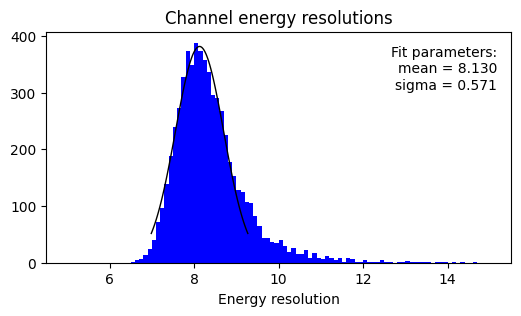

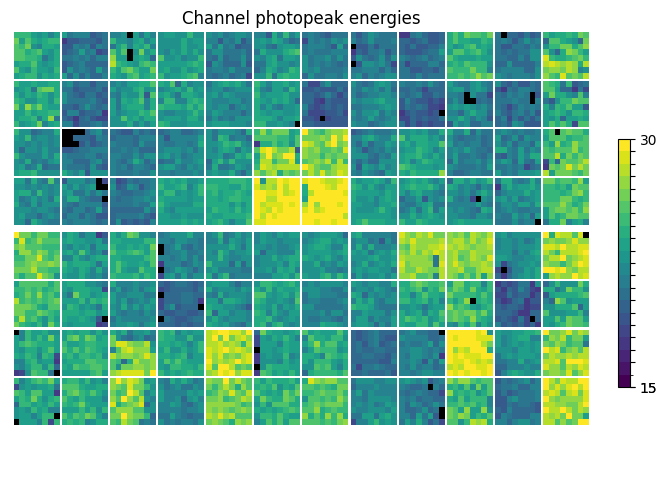

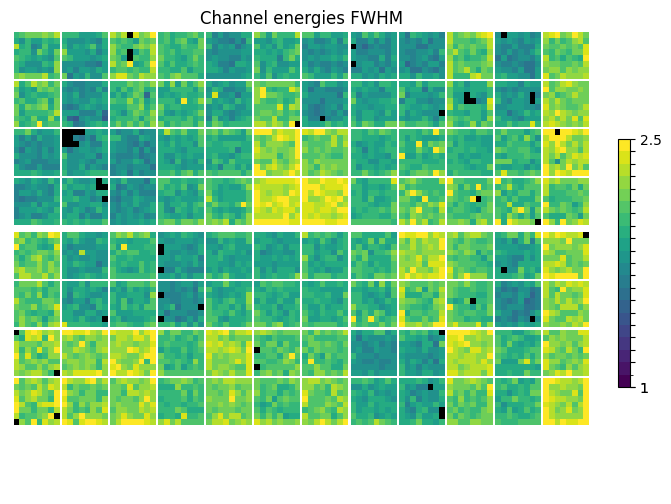

/tmp/ipykernel_2090757/1336000224.py:4: RuntimeWarning: invalid value encountered in divide
  makeheatmap(ppbounds[i][:, 3] / ppbounds[i][:, 2], 'Channel energy resolution', f'{names[i]}eres', savepath, heatmapmin = 0.06, heatmapmax = 0.12)


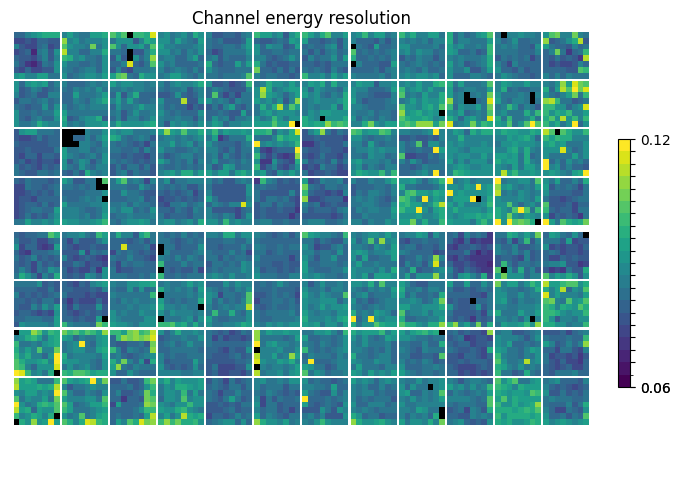

/tmp/ipykernel_2090757/1336000224.py:6: RuntimeWarning: invalid value encountered in divide
  eres = ppbounds[i][:, 3] / ppbounds[i][:, 2]


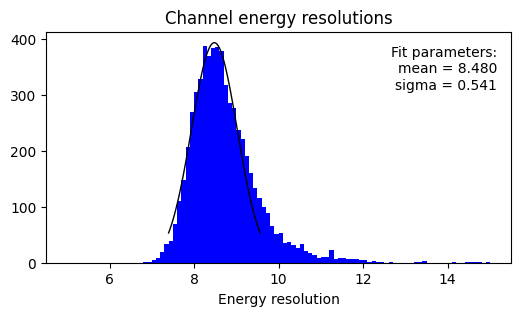

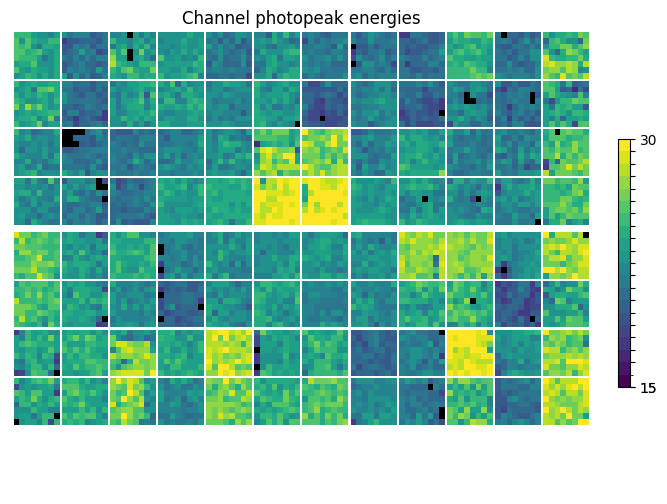

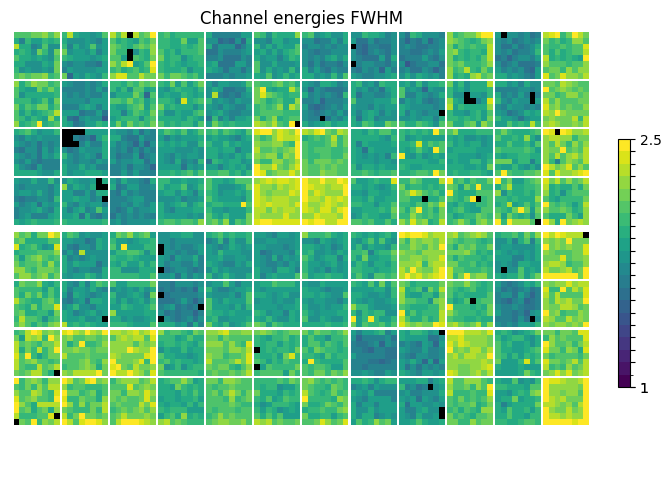

/tmp/ipykernel_2090757/1336000224.py:4: RuntimeWarning: invalid value encountered in divide
  makeheatmap(ppbounds[i][:, 3] / ppbounds[i][:, 2], 'Channel energy resolution', f'{names[i]}eres', savepath, heatmapmin = 0.06, heatmapmax = 0.12)


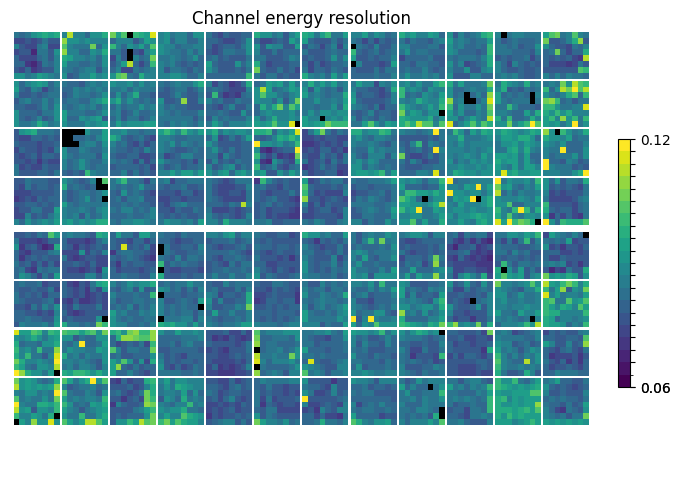

/tmp/ipykernel_2090757/1336000224.py:6: RuntimeWarning: invalid value encountered in divide
  eres = ppbounds[i][:, 3] / ppbounds[i][:, 2]


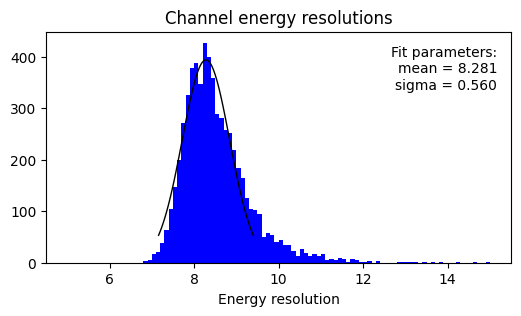

In [8]:
for i in range(len(ppbounds)):
    makeheatmap(ppbounds[i][:, 2], 'Channel photopeak energies', f'{names[i]}photopeaks', savepath, heatmapmin = 15, heatmapmax = 30)
    makeheatmap(ppbounds[i][:, 3], 'Channel energies FWHM', f'{names[i]}efwhm', savepath, heatmapmin = 1, heatmapmax = 2.5)
    makeheatmap(ppbounds[i][:, 3] / ppbounds[i][:, 2], 'Channel energy resolution', f'{names[i]}eres', savepath, heatmapmin = 0.06, heatmapmax = 0.12)
    plt.figure(i, figsize = (6, 3))
    eres = ppbounds[i][:, 3] / ppbounds[i][:, 2]
    eres = eres[~np.isnan(eres)] * 100
    hist, bins = plt.hist(eres, bins = np.linspace(5, 15, 101), color = 'blue', alpha = 1)[0:2]
    bincenters = bins[:-1] + (bins[1] - bins[0]) / 2
    maxindex = np.argmax(hist)
    popt, pcov = curve_fit(lambda x, a, mu, sigma: a * np.exp(-(x - mu)**2 / (2 * sigma**2)), bincenters[maxindex-10:maxindex + 10], hist[maxindex - 10:maxindex + 10], p0 = [100, 8, 1])
    popt[2] = np.abs(popt[2])
    plottingrange = [popt[1] - 2 * popt[2], popt[1] + 2 * popt[2]]
    plt.plot(np.linspace(plottingrange[0], plottingrange[1], 100), popt[0] * np.exp(-(np.linspace(plottingrange[0], plottingrange[1], 100) - popt[1])**2 / (2 * popt[2]**2)), color = 'black', linewidth = 1)
    plt.title(f'Channel energy resolutions')
    plt.xlabel('Energy resolution')
    text = f'Fit parameters:\nmean = {popt[1]:.3f}\nsigma = {np.abs(popt[2]):.3f}'
    plt.text(0.97, 0.94, text, color='black', fontsize=10, ha='right', va='top',
        transform=plt.gca().transAxes)
    plt.savefig(os.path.join(savepath, f'{names[i]}eres.pdf'), format='pdf', dpi=300, bbox_inches='tight')
    plt.show()